In [ ]:
import random as random
import numpy as np

In [ ]:
from IPython.core.interactiveshell import dis
class KMeans:
  def __init__(self, n_clusters=2, max_iter=100):
    self.n_clusters = n_clusters
    self.max_iter = max_iter
    self.centroids = None

  def fit_predict(self, X):
    random_index = random.sample(range(0,X.shape[0]),self.n_clusters)
    self.centroids = X[random_index]

    for i in range(self.max_iter):
      #assign clusters
      cluster_group = self.assign_clusters(X)
      old_centroids = self.centroids

      # move centroids
      self.centroids = self.move_centroids(X,cluster_group)
      #check finish
      if np.array_equal(old_centroids, self.centroids):
        break
    return cluster_group

  def assign_clusters(self, X):
    cluster_group = []
    distances = []

    for row in X:
      for centroid in self.centroids:
        distance = np.sqrt(np.dot(row-centroid, row-centroid))
        distances.append(distance)
      min_distance = min(distances)
      min_distance_index = distances.index(min_distance)
      cluster_group.append(min_distance_index)
      distances.clear()
    return np.array(cluster_group)

  def move_centroids(self,X,cluster_group):
    new_centroids = []

    cluster_type = np.unique(cluster_group)

    for k in cluster_type:
      new_centroids.append(X[cluster_group==k].mean(axis=0))
    return np.array(new_centroids)

In [ ]:
from sklearn.datasets import make_blobs
centroids = [(-5,5),(5,5),(-2.5,2.5),(2.5,-2.5)]
cluster_std = [1,1,1,1]
X,y = make_blobs(n_samples = 100, cluster_std = cluster_std, centers = centroids, n_features = 2, random_state = 2)

In [ ]:
y

array([0, 1, 0, 1, 3, 0, 0, 2, 1, 3, 3, 3, 0, 3, 3, 3, 2, 1, 1, 1, 1, 1,
       3, 0, 3, 0, 3, 0, 1, 2, 3, 2, 0, 1, 0, 0, 3, 2, 3, 2, 0, 1, 2, 2,
       1, 2, 3, 0, 3, 3, 0, 1, 2, 2, 2, 1, 2, 1, 2, 0, 2, 0, 1, 2, 3, 0,
       2, 2, 2, 1, 2, 0, 0, 1, 2, 1, 1, 2, 2, 1, 3, 3, 3, 0, 3, 1, 0, 2,
       1, 0, 3, 1, 0, 2, 3, 1, 3, 0, 0, 3])

In [ ]:
km = KMeans(4,400)
y_means =km.fit_predict(X)

In [ ]:
import matplotlib.pyplot as plt

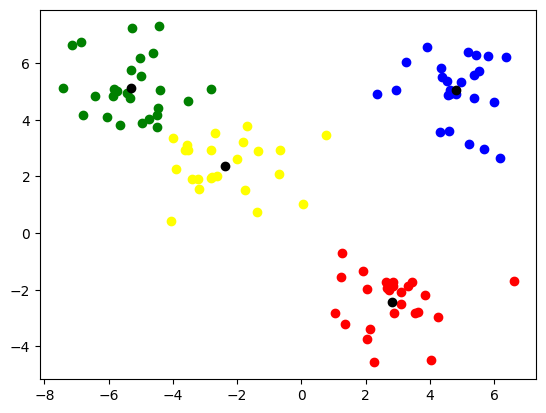

In [ ]:
plt.scatter(X[y_means == 0,0],X[y_means == 0,1],c='red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],c='blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],c='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],c='yellow')
plt.scatter(km.centroids[:,0],km.centroids[:,1],c='black')
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv('/content/student_clustering.csv')

In [ ]:
X= df.iloc[:,:].values

In [ ]:
X

array([[  5.13,  88.  ],
       [  5.9 , 113.  ],
       [  8.36,  93.  ],
       [  8.27,  97.  ],
       [  5.45, 110.  ],
       [  5.88, 109.  ],
       [  8.41,  98.  ],
       [  8.8 , 115.  ],
       [  5.79, 110.  ],
       [  8.09,  94.  ],
       [  4.6 ,  86.  ],
       [  6.1 , 110.  ],
       [  8.16,  97.  ],
       [  5.  ,  88.  ],
       [  5.71, 108.  ],
       [  8.31,  95.  ],
       [  5.5 , 111.  ],
       [  7.87,  91.  ],
       [  6.05, 111.  ],
       [  5.84, 113.  ],
       [  7.47,  98.  ],
       [  4.86,  86.  ],
       [  7.78,  92.  ],
       [  4.78,  87.  ],
       [  4.96,  88.  ],
       [  7.93,  98.  ],
       [  4.86,  87.  ],
       [  9.18, 119.  ],
       [  8.04,  94.  ],
       [  5.43, 106.  ],
       [  8.86, 117.  ],
       [  6.01, 112.  ],
       [  8.83, 118.  ],
       [  5.32, 106.  ],
       [  7.77,  96.  ],
       [  8.  ,  96.  ],
       [  8.56, 118.  ],
       [  5.91, 108.  ],
       [  5.44,  84.  ],
       [  5.57, 113.  ],


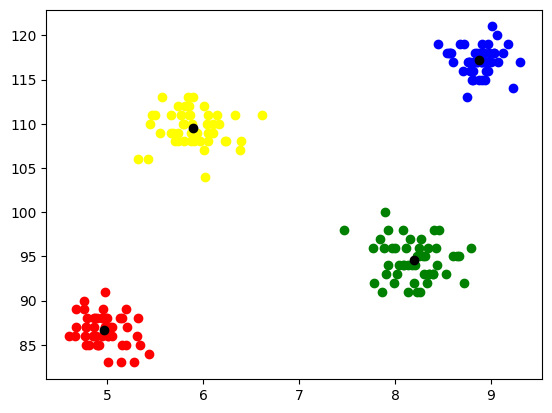

In [ ]:
km = KMeans(n_clusters = 4, max_iter = 400)
y_means = km.fit_predict(X)
plt.scatter(X[y_means == 0,0],X[y_means == 0,1],c='red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],c='blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],c='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],c='yellow')
plt.scatter(km.centroids[:,0],km.centroids[:,1],c='black')
plt.show()

Hierarchical clustering

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
import numpy as np
customer_data = pd.read_csv('hierarchical-clustering-with-python-and-scikit-learn-shopping-data.csv')
customer_data.shape

(200, 5)

In [ ]:
data = customer_data.iloc[:, 3:5].values
data

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

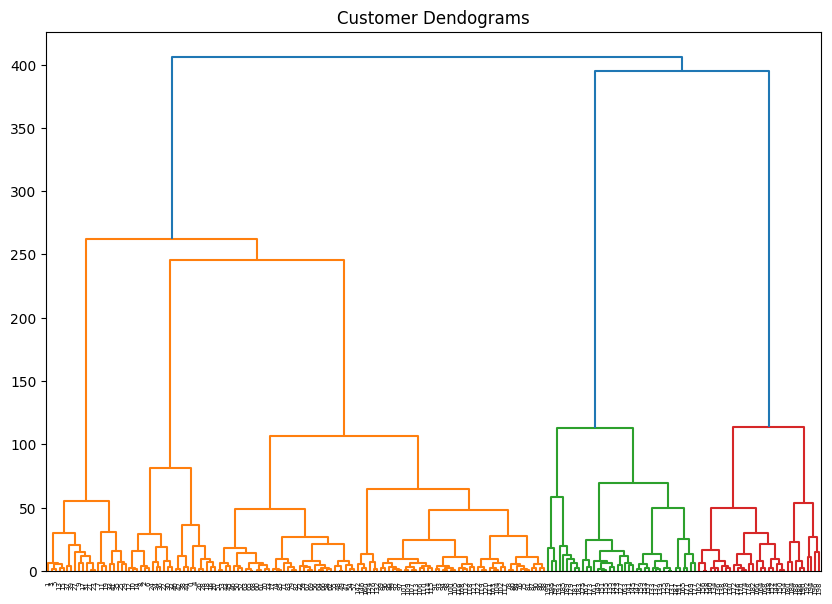

In [ ]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10, 7))
plt.title("Customer Dendograms")
dend = shc.dendrogram(shc.linkage(data, method="ward"))

In [ ]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
labels_ = cluster.fit_predict(data)
print(labels_)

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 1 2
 0 2 0 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


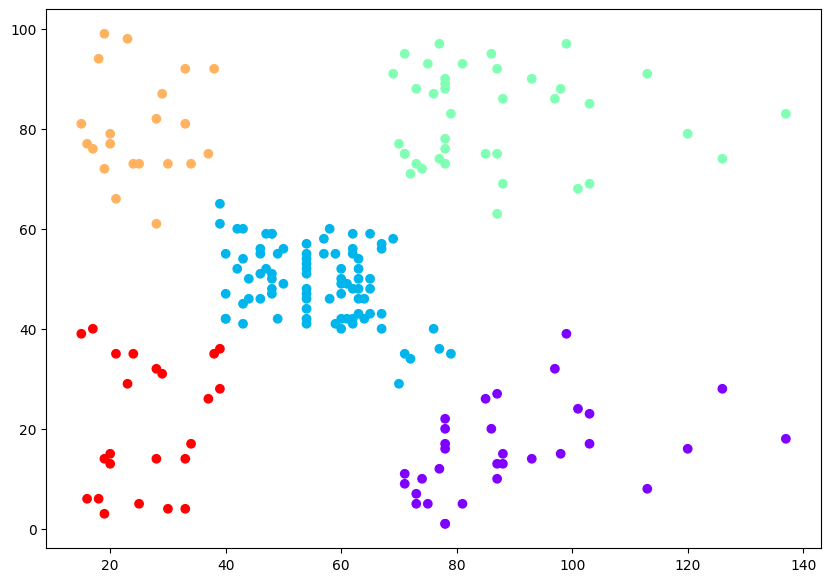

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(data[:,0], data[:,1], c = labels_, cmap = 'rainbow')